**Demand Forecasting Project**

In [ ]:
from google.colab import files
uploaded =files.upload()

Saving demand_forecasting.csv to demand_forecasting.csv


**1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**🔹 2. Load Dataset**

In [ ]:
df = pd.read_csv('demand_forecasting.csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


**3. Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

**4. Check Missing Values**

In [ ]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


**5. Data Preprocessing Convert Date Column**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

**6. Exploratory Data Analysis (EDA)**

In [ ]:
df['Demand'].describe()

,Demand
count,76000.000000
mean,104.317158
std,46.964801
min,4.000000
25%,71.000000
50%,100.000000
75%,133.000000
max,430.000000


**Demand by Category**

In [ ]:
category_demand = df.groupby('Category')['Demand'].sum()
print(category_demand)

Category
Clothing       1369456
Electronics     889036
Furniture      1006590
Groceries      3677684
Toys            985338
Name: Demand, dtype: int64


**Demand by Region**

In [ ]:
region_demand = df.groupby('Region')['Demand'].sum()
print(region_demand)

Region
East     1618324
North    3154658
South    1625471
West     1529651
Name: Demand, dtype: int64


**7. Data Visualization(Demand by Category)**

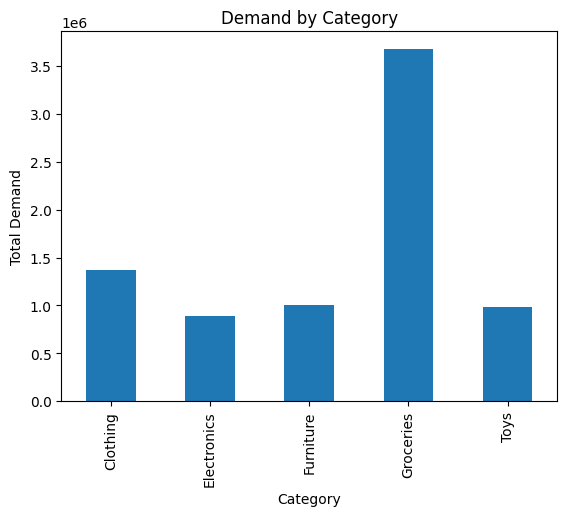

In [ ]:
category_demand.plot(kind='bar')
plt.title('Demand by Category')
plt.xlabel('Category')
plt.ylabel('Total Demand')
plt.show()

**Demand by Region**

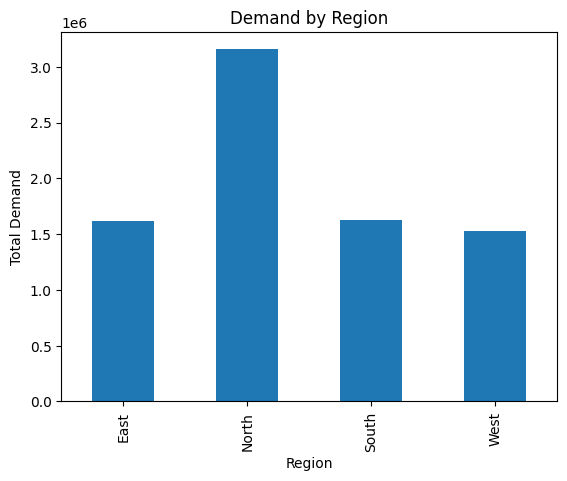

In [ ]:
region_demand.plot(kind='bar')
plt.title('Demand by Region')
plt.xlabel('Region')
plt.ylabel('Total Demand')
plt.show()

**8. Feature Selection**

In [ ]:
X = df.drop(['Demand', 'Date'], axis=1)
y = df['Demand']

**9. Encode Categorical Data**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

**10. Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Drop Date column
X = df.drop(['Demand', 'Date'], axis=1)
y = df['Demand']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])